2025-08-02 12:39:34 — INFO — Notebook start.
2025-08-02 12:39:34 — INFO — Installing python-dotenv (missing)
2025-08-02 12:39:35 — INFO — Installing Pillow (missing)
2025-08-02 12:39:36 — INFO — GenAI backend: Dev API
2025-08-02 12:39:36 — INFO — SLIM_ACR dataset found at D:\Projects\gemini_image_segmentation\data\SLIM_ACR
2025-08-02 12:39:36 — INFO — Cache not found. Scanning all masks for positive cases (this may take a while)...
Scanning for positive cases: 100%|██████████| 10675/10675 [00:16<00:00, 637.36it/s]
2025-08-02 12:39:54 — INFO — Saving positive case list to cache: D:\Projects\gemini_image_segmentation\data\SLIM_ACR\positive_cases_cache.txt
2025-08-02 12:39:54 — INFO — 2379 total positive pneumothorax cases collected.
2025-08-02 12:39:54 — INFO — Selected sample image: 1.2.276.0.7230010.3.1.4.8323329.3432.1517875177.822407.png
2025-08-02 12:39:54 — INFO — Starting Gemini API call.
2025-08-02 12:39:54 — INFO — AFC is enabled with max remote calls: 10.
2025-08-02 12:39:57 — 

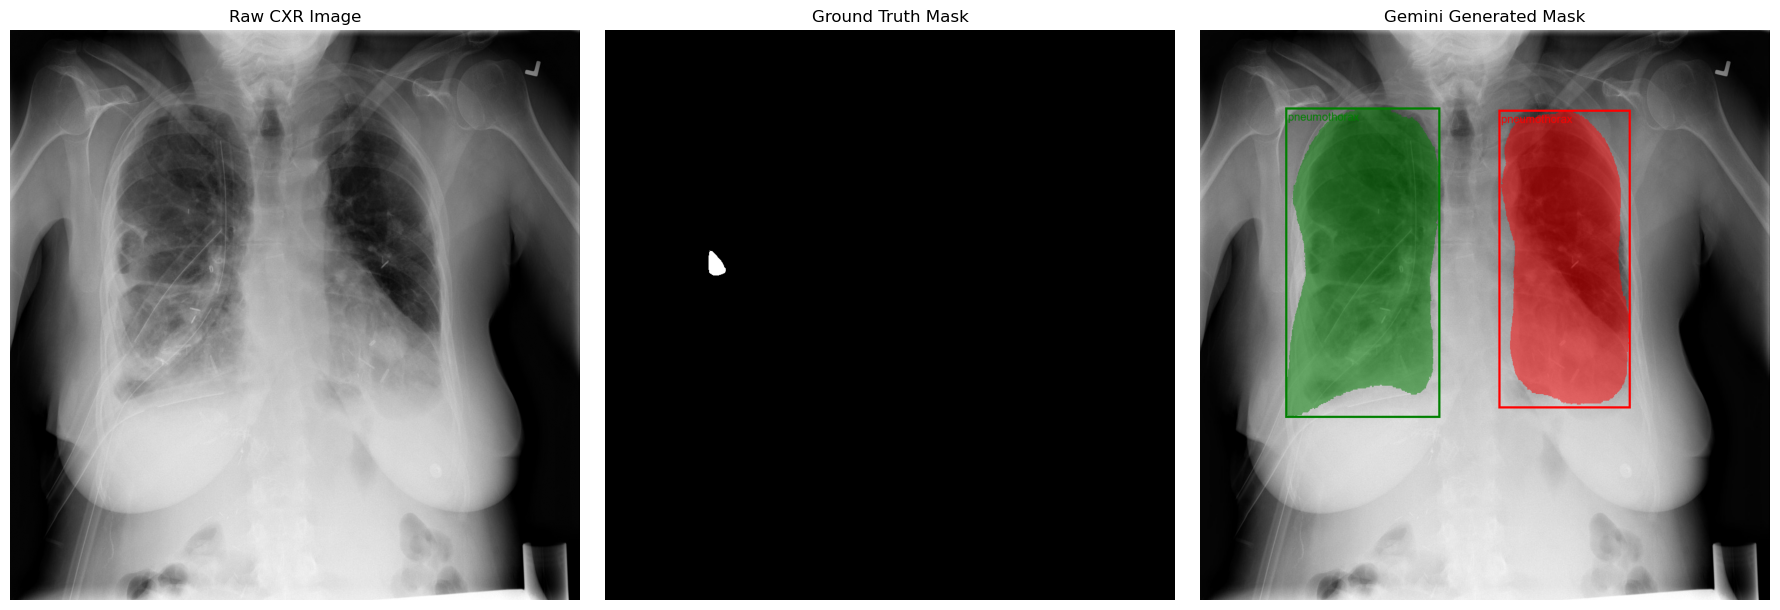

'\n✅ Environment verified, SLIM_ACR dataset indexed and filtered, Gemini smoke-test executed with correct parsing logic.\nNext step: Run a batch evaluation on the collected positive cases.\n'

In [ ]:
# %% [markdown]
"""
# 01 Environment & Data Prep · **LITS Edition** (uses `environment.yml`)

*Last sync 02 Aug 2025* This script adapts the original segmentation workflow for the LITS
(Liver Tumor Segmentation) abdominal CT dataset. It calls the Gemini API to identify and mask
the liver in CT slices.
- `gemini-2.5-flash` model
- Thinking disabled (`thinking_budget=0`)
- A clear, conversational prompt requesting a JSON list of masks for a specific pathology.
- **Correctly parses the API's output of partial masks within bounding boxes.**
- **Visualizes the final masks overlaid on the original image.**

**Changelog (Adapted for LITS)**
* **MODIFIED** dataset paths to point to the LITS data structure (`data/LITS/`).
* **MODIFIED** the data loading logic to parse `lits_df.csv` as the source of truth.
* **ADDED** path correction logic to align CSV paths with the local filesystem.
* **ADDED** a validation step to compare positive cases from the CSV vs. a live scan of mask files.
* **MODIFIED** the `PROMPT` to request segmentation of the "liver" in an "abdominal CT".
* **RENAMED** variables and log messages for clarity (e.g., `ct_slice`, `lits_df`).
"""

# %%
# ---------- Preamble
import sys, logging, os, subprocess, importlib.util, json, io, random, base64, dataclasses
from datetime import datetime
from pathlib import Path
from typing import Tuple, Optional, List
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageColor, UnidentifiedImageError
from tqdm import tqdm

assert sys.version_info >= (3, 11), (
    f"Python 3.11+ required, found {sys.version.split()[0]}")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Notebook start.")

# %%
# ---------- Ensure helper packages

def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

# MODIFIED: Added pandas for CSV handling
for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow", "pandas"):
    _ensure(extra)

# %%
# ---------- GenAI client
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=False)

from google import genai
from google.genai.types import GenerateContentConfig, Part, ThinkingConfig

if not os.getenv("GOOGLE_API_KEY"):
    raise ValueError("GOOGLE_API_KEY not found. Ensure it is in your .env file.")

client = genai.Client()
logging.info("GenAI backend: %s", "Vertex" if client.vertexai else "Dev API")

# %%
# ---------- Configuration
# MODIFIED: New variable to define the segmentation target.
# Can be switched to "tumor" for the next phase.
SEGMENTATION_TARGET = "liver" 

# MODIFIED: Point to the LITS dataset directory.
dataset_dir = Path("data/LITS").expanduser().resolve()
lits_csv_path = dataset_dir / "lits_df.csv"

if not lits_csv_path.is_file():
    logging.error("LITS CSV not found at the specified path.")
    raise FileNotFoundError(
        f"Expected 'lits_df.csv' inside {dataset_dir}. "
        "Please ensure the LITS dataset is correctly placed."
    )
logging.info("LITS dataset found at %s", dataset_dir)


# %%
# ---------- Load and Prepare Data from CSV

def correct_path(p: str, base_dir: Path) -> Path:
    """Corrects the path from the CSV to match the local filesystem."""
    # Example CSV path: ../input/lits-png/dataset_6/volume-0_0.png
    # We want to map it to: data/LITS/dataset_6/volume-0_0.png
    parts = Path(p).parts
    # The last two parts are typically 'dataset_6' and 'volume-0_0.png'
    if len(parts) >= 2:
        return base_dir / parts[-2] / parts[-1]
    return Path(p) # Return original if format is unexpected

logging.info("Loading and processing %s", lits_csv_path.name)
lits_df = pd.read_csv(lits_csv_path)

# Correct the paths in the dataframe
path_cols = ['filepath', 'liver_maskpath', 'tumor_maskpath']
for col in path_cols:
    lits_df[col] = lits_df[col].apply(lambda x: correct_path(x, dataset_dir))

# Define which columns to use based on the segmentation target
if SEGMENTATION_TARGET == "liver":
    mask_path_col = 'liver_maskpath'
    mask_empty_col = 'liver_mask_empty'
elif SEGMENTATION_TARGET == "tumor":
    mask_path_col = 'tumor_maskpath'
    mask_empty_col = 'tumor_mask_empty'
else:
    raise ValueError(f"Invalid SEGMENTATION_TARGET: {SEGMENTATION_TARGET}")

logging.info("Set segmentation target to: '%s'", SEGMENTATION_TARGET)


# %%
# ---------- Validate Positive Cases: CSV vs. Live Scan

def check_mask_for_positive_finding(mask_path: Path) -> Optional[Path]:
    """
    Checks if a mask has a positive finding (any non-black pixels).
    Returns the mask path if positive, otherwise None.
    """
    if mask_path.exists():
        try:
            with Image.open(mask_path) as mask_img:
                mask_array = np.array(mask_img)
                if np.any(mask_array > 0):
                    return mask_path
        except UnidentifiedImageError:
            logging.warning("Could not read mask file, skipping: %s", mask_path)
    return None

# --- Method 1: Get positive cases from the CSV file ---
logging.info("Identifying positive cases based on '%s' column in CSV...", mask_empty_col)
positive_df_from_csv = lits_df[lits_df[mask_empty_col] == False]
positive_masks_from_csv = set(positive_df_from_csv[mask_path_col])
logging.info("Found %d positive cases according to the CSV.", len(positive_masks_from_csv))

# --- Method 2: Scan all mask files directly ---
logging.info("Scanning all %d mask files on disk to find positive cases...", len(lits_df))
all_mask_paths = lits_df[mask_path_col].tolist()
positive_masks_from_scan_list = []

with ThreadPoolExecutor() as executor:
    results = list(tqdm(
        executor.map(check_mask_for_positive_finding, all_mask_paths),
        total=len(all_mask_paths),
        desc=f"Scanning {SEGMENTATION_TARGET} masks"
    ))

positive_masks_from_scan = set(path for path in results if path is not None)
logging.info("Found %d positive cases by scanning mask files.", len(positive_masks_from_scan))

# --- Compare the results ---
if positive_masks_from_csv == positive_masks_from_scan:
    logging.info("Validation successful: CSV and live scan results match perfectly.")
else:
    logging.warning("Discrepancy found between CSV and live scan results!")
    csv_only = positive_masks_from_csv - positive_masks_from_scan
    scan_only = positive_masks_from_scan - positive_masks_from_csv
    if csv_only:
        logging.warning("%d masks are marked non-empty in CSV but appear empty on scan.", len(csv_only))
    if scan_only:
        logging.warning("%d masks are marked empty in CSV but have content on scan.", len(scan_only))

# --- Populate the final dataset for the API call ---
# We will use the CSV as the source of truth for this run.
dataset = []
for _, row in positive_df_from_csv.iterrows():
    img_path = row['filepath']
    mask_path = row[mask_path_col]
    if img_path.exists() and mask_path.exists():
        dataset.append((img_path, mask_path))

assert dataset, "No positive image-mask pairs found in the dataset!"
logging.info(
    "%d total positive '%s' cases collected for segmentation.", len(dataset), SEGMENTATION_TARGET
)


# %%
# ---------- Segmentation Utils

@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def parse_json(json_output: str) -> str:
    """Cleans the model's JSON output by removing markdown fencing."""
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line.strip() == "```json":
            json_content = "\n".join(lines[i+1:])
            closing_fence_index = json_content.find("```")
            if closing_fence_index != -1:
                json_content = json_content[:closing_fence_index]
            return json_content.strip()
    return json_output.strip()

def parse_segmentation_masks(
    predicted_str: str, *, img_height: int, img_width: int
) -> list[SegmentationMask]:
    """Parses the model's JSON output into a list of SegmentationMask objects."""
    cleaned_json = parse_json(predicted_str)
    if not cleaned_json:
        logging.warning("Parsing model output resulted in an empty string.")
        return []

    try:
        items = json.loads(cleaned_json)
    except json.JSONDecodeError as e:
        logging.error(f"Failed to decode JSON: {e}")
        logging.error(f"Problematic string after cleaning: {cleaned_json}")
        return []

    masks = []
    for item in items:
        try:
            abs_y0 = int(item["box_2d"][0] / 1000 * img_height)
            abs_x0 = int(item["box_2d"][1] / 1000 * img_width)
            abs_y1 = int(item["box_2d"][2] / 1000 * img_height)
            abs_x1 = int(item["box_2d"][3] / 1000 * img_width)

            if abs_y0 >= abs_y1 or abs_x0 >= abs_x1:
                logging.warning("Skipping item with invalid bounding box: %s", item["box_2d"])
                continue

            label = item["label"]
            png_b64_str = item["mask"]

            if not png_b64_str.startswith("data:image/png;base64,"):
                logging.warning("Skipping item with invalid mask format for label '%s'", label)
                continue

            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            partial_mask_img = Image.open(io.BytesIO(png_bytes))

            bbox_height = abs_y1 - abs_y0
            bbox_width = abs_x1 - abs_x0
            if bbox_height < 1 or bbox_width < 1:
                logging.warning("Skipping item with zero-area bounding box for label '%s'", label)
                continue

            resized_mask = partial_mask_img.resize((bbox_width, bbox_height), resample=Image.Resampling.BILINEAR)
            full_mask_np = np.zeros((img_height, img_width), dtype=np.uint8)
            full_mask_np[abs_y0:abs_y1, abs_x0:abs_x1] = np.array(resized_mask)

            masks.append(SegmentationMask(abs_y0, abs_x0, abs_y1, abs_x1, full_mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.error(f"Skipping malformed item in JSON response: {item}. Error: {e}")
            continue
    return masks

def overlay_mask_on_img(img: Image.Image, mask: np.ndarray, color: str, alpha: float = 0.5) -> Image.Image:
    """Overlays a single mask onto a PIL Image."""
    color_rgb = ImageColor.getrgb(color)
    img_rgba = img.convert("RGBA")
    overlay_color_rgba = color_rgb + (int(alpha * 255),)

    colored_mask_layer_np = np.zeros((img.height, img.width, 4), dtype=np.uint8)
    mask_binary = mask > 127
    colored_mask_layer_np[mask_binary] = overlay_color_rgba
    colored_mask_layer_pil = Image.fromarray(colored_mask_layer_np, 'RGBA')

    return Image.alpha_composite(img_rgba, colored_mask_layer_pil)

def plot_segmentation_masks(img: Image.Image, segmentation_masks: list[SegmentationMask]) -> Image.Image:
    """Draws all masks, bounding boxes, and labels on an image."""
    if not segmentation_masks:
        return img.convert("RGB")

    colors = ["red", "green", "blue", "yellow", "purple", "orange", "cyan", "magenta"]
    try:
        font = ImageFont.truetype("arial.ttf", size=20)
    except IOError:
        logging.warning("Arial font not found, using default. Labels may be small.")
        font = ImageFont.load_default()

    img_with_masks = img.copy()
    for i, seg_mask in enumerate(segmentation_masks):
        color = colors[i % len(colors)]
        img_with_masks = overlay_mask_on_img(img_with_masks, seg_mask.mask, color)

    draw = ImageDraw.Draw(img_with_masks)
    for i, seg_mask in enumerate(segmentation_masks):
        color = colors[i % len(colors)]
        box = ((seg_mask.x0, seg_mask.y0), (seg_mask.x1, seg_mask.y1))
        draw.rectangle(box, outline=color, width=4)
        if seg_mask.label:
            text_position = (seg_mask.x0 + 5, seg_mask.y0 + 5)
            draw.text(text_position, seg_mask.label, fill=color, font=font)

    return img_with_masks.convert("RGB")


# %%
# ---------- Gemini smoke-test (Refactored)

MODEL_NAME = "gemini-2.5-flash"
# MODIFIED: Prompt updated for liver segmentation in an abdominal CT.
PROMPT = (
    f'In this slice of an abdominal CT, give the segmentation mask for the {SEGMENTATION_TARGET}. '
    'Output a JSON list of segmentation masks where each entry contains the 2D bounding box in the key "box_2d", '
    'the segmentation mask in key "mask", and the text label in the key "label". '
    f'Use the label "{SEGMENTATION_TARGET}".'
)

def gemini_seg(image_obj: Image.Image) -> Tuple[list[SegmentationMask], float]:
    """
    Sends a PIL Image object to Gemini and returns a list of SegmentationMasks.

    Args:
        image_obj: A PIL.Image.Image object to be segmented.

    Returns:
        A tuple containing:
        - A list of SegmentationMask objects.
        - The latency of the API call in seconds.
    """
    logging.info("Starting Gemini API call.")
    original_width, original_height = image_obj.size
    
    try:
        # 1. Copy the image to avoid modifying the original object
        img_for_api = image_obj.copy()

        # 2. Resize for the API call if necessary
        max_dim = 1024
        if img_for_api.height > max_dim or img_for_api.width > max_dim:
            img_for_api.thumbnail((max_dim, max_dim))
            logging.info(f"Resized image from {original_width}x{original_height} to {img_for_api.size} for API call.")

        # 3. Convert the (potentially resized) PIL image to bytes
        with io.BytesIO() as img_byte_arr:
            img_for_api.save(img_byte_arr, format='PNG')
            img_bytes = img_byte_arr.getvalue()

        # 4. Define the generation configuration
        gen_config = GenerateContentConfig(
            thinking_config=ThinkingConfig(thinking_budget=0),
            temperature=0.5
        )

        # 5. Create explicit Part objects for the request
        image_part = Part.from_bytes(data=img_bytes, mime_type='image/png')
        text_part = Part(text=PROMPT)

        # 6. Send the request
        start_time = datetime.now()
        response = client.models.generate_content(
            model=MODEL_NAME,
            contents=[image_part, text_part],
            config=gen_config,
        )
        latency = (datetime.now() - start_time).total_seconds()
        logging.info("Gemini latency %.2fs", latency)

        # 7. Parse the response using the utility function
        logging.info("Received response from Gemini. Parsing masks...")
        masks = parse_segmentation_masks(
            response.text,
            img_height=original_height,
            img_width=original_width
        )
        logging.info("Found %d segmentation masks.", len(masks))
        return masks, latency

    except Exception as e:
        logging.error("An error occurred during the gemini_seg function.", exc_info=True)
        return [], 0.0

# %%
# ---------- Main Execution and Visualization ----------
# Select a random sample and open the image ONCE.
sample_img_path, sample_mask_path = random.choice(dataset)
logging.info("Selected sample image: %s", sample_img_path.name)
original_image = Image.open(sample_img_path)

# Execute the segmentation by passing the Image object
gemini_masks, _ = gemini_seg(original_image)

# Visualize the results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original Image
ax[0].imshow(original_image, cmap='gray')
ax[0].set_title("Raw CT Slice")
ax[0].axis("off")

# 2. Ground Truth Mask
try:
    ground_truth_mask = Image.open(sample_mask_path)
    ax[1].imshow(ground_truth_mask, cmap='gray')
    ax[1].set_title(f"Ground Truth {SEGMENTATION_TARGET.title()} Mask")
except FileNotFoundError:
    ax[1].text(0.5, 0.5, 'Mask Not Found', ha='center', va='center')
    ax[1].set_title("Ground Truth Mask (not found)")
ax[1].axis("off")

# 3. Gemini Generated Mask
if gemini_masks:
    composite_image = plot_segmentation_masks(original_image, gemini_masks)
    ax[2].imshow(composite_image)
    ax[2].set_title(f"Gemini Generated {SEGMENTATION_TARGET.title()} Mask")
else:
    ax[2].imshow(original_image, cmap='gray')
    ax[2].text(0.5, 0.5, 'Mask Generation Failed', ha='center', va='center', color='red',
               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))
    ax[2].set_title("Gemini (failed)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

# %% [markdown]
"""
✅ Environment verified, LITS dataset indexed, validated, and filtered.
Gemini smoke-test executed with correct parsing logic for liver segmentation.
Next step: Analyze results and potentially switch `SEGMENTATION_TARGET` to "tumor".
"""
